In [1]:
from dotenv import load_dotenv
load_dotenv()

import os

import numpy as np
from pixell import enmap, enplot, reproject
import glob
import matplotlib.pyplot as plt
import emcee, corner
from astropy.io import fits
import sys
from astropy import units as u, constants as const
sys.path.insert(0, '../src')
#sys.path.insert(0, "/home/gill/apps/szpack/python")
import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
import yaml
import itertools
from pixell import enmap

import bandpass as bp
import covariance as cov
import model
import utils as ut

import SZpack as SZ

from astropy.coordinates import SkyCoord
import astropy.units as u

In [2]:
cf = ut.get_config_file("../configs/case10_ajay.yaml")
region = ut.get_region(cf['region_center_ra'], 
                        cf['region_center_dec'], 
                        1.2)

norm_const = -3.526666833214854e-07 * 10**5
y_map_normal = enmap.read_map("/home/gill/research/ACT/paper/models/ymaps/regular.fits", box=region) * norm_const
y_map_clusters = enmap.read_map("/home/gill/research/ACT/paper/models/ymaps/clusters_only.fits", box=region) * norm_const
y_map_all = enmap.read_map("/home/gill/research/ACT/paper/models/ymaps/all.fits", box=region) * norm_const

models_best_fit_clusters = enmap.read_map("/home/gill/research/ACT/paper/models/indiv/total_model_only_clusters_full_map//models/model_98_pa5.fits", box=region) 
models_best_fit_all = enmap.read_map("/home/gill/research/ACT/paper/models/indiv/total_model_all_three_systems_full_map//models/model_98_pa5.fits", box=region) 

# print mean and std of y_map_normal
print("y_map_normal mean:", np.mean(y_map_normal))
print("y_map_normal std:", np.std(y_map_normal))

best_fit_tSZ = enmap.read_map("/home/gill/research/ACT/paper/x_ray_radio/bridge_indv_98_pa5_model_uK_all.fits", box=region)
best_fit_sigma = np.std(best_fit_tSZ)
best_fit_contour_levels = np.array([-5, -4, -3, -2, -1.7, -1]) * best_fit_sigma

y_map_normal mean: 0.23058788952558398
y_map_normal std: 0.9928289450527078


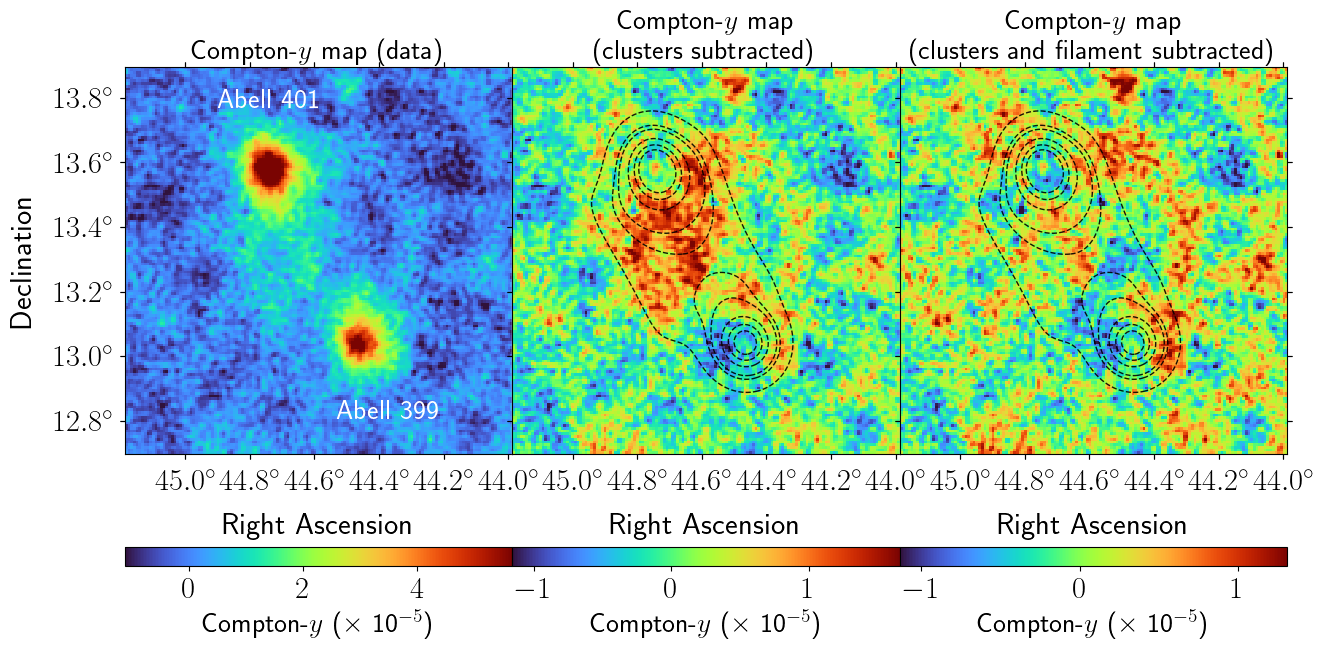

In [4]:
from astropy.visualization import ZScaleInterval, ImageNormalize, LogStretch, AsinhStretch, simple_norm

# Use LaTeX for the plot
plt.rc('text', usetex=True)
plt.rc('font', family='sans-serif', size=22)

# Create the plot with three subplots using WCS projection
fig = plt.figure(figsize=(15, 8))

# Define titles and maps
maps = [y_map_normal, y_map_clusters, y_map_all]
titles = ['Compton-$y$ map (data)', 'Compton-$y$ map \n (clusters subtracted)', 'Compton-$y$ map \n (clusters and filament subtracted)']

# Create subplots with WCS projection
for i, (y_map, title) in enumerate(zip(maps, titles)):
    ax = plt.subplot(1, 3, i+1, projection=y_map.wcs)
    #y_map *= 1e6  # Convert to micro-Kelvin
    # Compute ZScale limits for better contrast and use inverted plasma colormap
    cmap = plt.cm.turbo  # Inverted plasma colormap
    norm = ImageNormalize(y_map, interval=ZScaleInterval())

    # Optionally apply Gaussian filter for smoothing
    gaussian_filter_flag = True
    if gaussian_filter_flag:
        from scipy.ndimage import gaussian_filter
        y_map = gaussian_filter(y_map, sigma=0.5)
    
    if i == 0:  # For the first subplot (data map), use simple norm for better contrast
        norm = simple_norm(y_map, stretch="linear", percent=99)  # Use simple norm for better contrast
    elif i == 1:  # For the second subplot (clusters subtracted), use asinh stretch
        norm = simple_norm(y_map, stretch="linear", percent=99.7)  # Use simple norm for better contrast
    elif i == 2:  # For the third subplot (all subtracted), use log stretch
        norm = simple_norm(y_map, stretch="linear", percent=99.7)
    # Display the map with ZScale normalization
    im = ax.imshow(y_map, origin='lower', cmap=cmap, norm=norm, interpolation='none')
    
    # Add contours based on subplot index
    if i == 1:  # clusters subtracted map - use clusters only model
        sigma = np.std(models_best_fit_clusters)
        mean = np.mean(models_best_fit_clusters)
        contour_levels = [mean - 5*sigma, mean - 3*sigma, mean - sigma]
        contours = ax.contour(best_fit_tSZ, levels=best_fit_contour_levels, colors='black', alpha=0.9, linewidths=1)
    elif i == 2:  # all subtracted map - use all model
        sigma = np.std(models_best_fit_all)
        mean = np.mean(models_best_fit_all)
        contour_levels = [mean - 5*sigma, mean - 3*sigma, mean - sigma]
        contours = ax.contour(best_fit_tSZ, levels=best_fit_contour_levels, colors='black', alpha=0.9, linewidths=1)
    # No contours for i == 0 (data map)
    
    # Set up coordinate axes
    ra = ax.coords[0]
    dec = ax.coords[1]
    
    # Set labels - only show declination label for first subplot
    ra.set_axislabel('Right Ascension')
    if i == 0:
        dec.set_axislabel('Declination')
    else:
        dec.set_axislabel('')
        dec.set_ticklabel_visible(False)  # Hide y-axis tick labels for subplots 2 and 3
    
    # Ensure tick labels are in float degrees
    ra.set_major_formatter('d.d')
    dec.set_major_formatter('d.d')
    
    # Invert x-axis for proper RA display
    ax.invert_xaxis()
    
    # Add title
    ax.set_title(title, fontsize=20)
    
    # Add colorbar for each subplot
    cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.15, shrink=1)
    cbar.set_label(label=r'Compton-$y$ ($\times$ 10$^{-5}$)', fontsize=20)
    
    # Add Abell cluster labels to the first map
    if i == 0:
        # Abell 401 position
        ax.text(cf['c1_ra'], cf['c1_dec'] + 0.2, 'Abell 401', transform=ax.get_transform('world'), 
                fontsize=20, color='white', ha='center', va='center', weight='bold')
        
        # Abell 399 position  
        ax.text(cf['c2_ra']-.1, cf['c2_dec'] - 0.2, 'Abell 399', transform=ax.get_transform('world'),
                fontsize=20, color='white', ha='center', va='center', weight='bold')

# Reduce horizontal space between subplots
plt.subplots_adjust(wspace=0.0)
plt.savefig('../plots/compton_y_maps_contours.pdf',  dpi=400, bbox_inches='tight')
plt.show()


In [ ]:
# matplotlib latex font settings
plt.rc('text', usetex=True)
plt.rc('font', family='sans-serif', size=20)

cf = ut.get_config_file("../configs/case10_ajay.yaml")
region = ut.get_region(44.741, 
                       13.58, 
                       0.2)

y_map_normal = enmap.read_map("/home/gill/research/ACT/paper/models/ymaps/regular.fits", box=region) * norm_const

RA_best_fit = 44.741 * u.deg
DEC_best_fit = 13.58 * u.deg

RA_best_fit_h22 = 44.751 * u.deg
DEC_best_fit_h22 = 13.572 * u.deg

RA_best_fit_h22_DD = 44.740 * u.deg
DEC_best_fit_h22_DD = 13.582 * u.deg

# plot the y map
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot(projection=y_map_normal.wcs) 
norm = simple_norm(y_map_normal, stretch="linear")

ax.imshow(y_map_normal, origin='lower', cmap='turbo', norm=norm)
# ax.set_title('Compton-$y$ map (data)', fontsize=18)
ax.set_xlabel('Right Ascension', fontsize=16)
ax.set_ylabel('Declination', fontsize=16)

# Add markers at both best fit positions with explicit degree units
ax.plot(RA_best_fit.to(u.deg).value, DEC_best_fit.to(u.deg).value, marker='x', color='white', markersize=10, markeredgewidth=1, transform=ax.get_transform('world'), label='This work')
ax.plot(RA_best_fit_h22.to(u.deg).value, DEC_best_fit_h22.to(u.deg).value, marker='x', color='green', markersize=10, markeredgewidth=1, transform=ax.get_transform('world'), label='H22 (non-dust deprojected)')
ax.plot(RA_best_fit_h22_DD.to(u.deg).value, DEC_best_fit_h22_DD.to(u.deg).value, marker='x', color='magenta', markersize=10, markeredgewidth=1, transform=ax.get_transform('world'), label='H22 (dust-deprojected)')

ra = ax.coords[0]
dec = ax.coords[1]
ra.set_major_formatter('d.dd')
dec.set_major_formatter('d.dd')

ax.invert_xaxis()  # Invert x-axis for proper RA display
ax.legend(loc='upper right', fontsize=14, framealpha=0.9, edgecolor='black', facecolor='darkgray')

# place a text saying "Abell 401" near the bottom of the map
ax.text(44.741, 13.5, 'Abell 401', transform=ax.get_transform('world'), 
        fontsize=25, color='black', ha='center', va='center', weight='bold')

cbar = plt.colorbar(ax.images[0], ax=ax, orientation='horizontal', pad=0.1, shrink=0.6)
cbar.set_label('Compton-$y$', fontsize=16)
cbar.formatter.set_powerlimits((0, 0))
cbar.update_ticks()
plt.tight_layout()
plt.savefig('../plots/compton_y_map_comparison.pdf', dpi=600, bbox_inches='tight')
plt.show()


In [ ]:
y_map_normal.wcs